# Erste Datenanalyse

Dieses Notebook lädt die Daten aus dem ucimlrepo. Es zeigt uns den Aufbau der Daten und gibt erste Eindrücke der vorhandenen Daten.

---

## 1. Setup & Daten laden



In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 

# Styling für bessere Visualisierungen
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# fetch dataset 
mushroom = fetch_ucirepo(id=73) 



## 2. Daten einlesen & erste Inspektion



In [2]:
# data (as pandas dataframes) 
X = mushroom.data.features 
y = mushroom.data.targets 
  
# metadata 
print(mushroom.metadata) 
print('-' * 20)

# variable information 
print(mushroom.variables) 
print('-' * 20)

# original data as pandas dataframe
df = mushroom.data.original

print(f"📏 Shape: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten\n")
print('-' * 20)

df.sample(10)


{'uci_id': 73, 'name': 'Mushroom', 'repository_url': 'https://archive.ics.uci.edu/dataset/73/mushroom', 'data_url': 'https://archive.ics.uci.edu/static/public/73/data.csv', 'abstract': 'From Audobon Society Field Guide; mushrooms described in terms of physical characteristics; classification: poisonous or edible', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 8124, 'num_features': 22, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['poisonous'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1981, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5959T', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': "This data set includes descriptions of hypothetical samples corresponding to 23 species of gilled mushrooms in the Agaricus and Lepiota Family (pp. 500-525).  Each species is identified as definitely edible, definitely po

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,poisonous
1401,f,y,y,t,a,f,c,b,p,e,...,w,w,p,w,o,p,n,y,g,e
3346,x,f,g,f,c,f,w,n,u,e,...,w,w,p,w,o,p,k,v,d,p
7699,b,s,n,f,n,a,c,b,o,e,...,o,o,p,o,o,p,n,v,l,e
6997,k,f,w,f,n,f,w,b,p,e,...,w,w,p,w,t,p,w,s,g,e
6980,k,s,n,f,y,f,c,n,b,t,...,w,w,p,w,o,e,w,v,l,p
2456,x,y,e,t,n,f,c,b,n,t,...,g,w,p,w,o,p,n,y,d,e
3491,f,f,e,t,n,f,c,b,w,t,...,g,p,p,w,o,p,n,y,d,e
6063,x,y,e,f,f,f,c,n,b,t,...,w,p,p,w,o,e,w,v,l,p
3051,f,y,n,t,n,f,c,b,n,t,...,g,g,p,w,o,p,k,v,d,e
4942,f,y,g,f,f,f,c,b,h,e,...,b,b,p,w,o,l,h,y,p,p




---

## 3. Datenqualität & Struktur



In [3]:
print("=" * 80)
print("📋 DATENÜBERSICHT")
print("=" * 80)

# Grundlegende Statistiken
print(f"\n🔢 Dimensionen: {df.shape[0]:,} Zeilen × {df.shape[1]} Spalten")
print(f"🔄 Duplikate: {df.duplicated().sum():,} ({df.duplicated().sum()/len(df)*100:.2f}%)")
print(f"💾 Speichernutzung: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")



📋 DATENÜBERSICHT

🔢 Dimensionen: 8,124 Zeilen × 23 Spalten
🔄 Duplikate: 0 (0.00%)
💾 Speichernutzung: 8.87 MB


In [4]:
# Detaillierte Spaltenübersicht
column_info = pd.DataFrame({
    "Datentyp": df.dtypes,
    "Fehlende Werte": df.isnull().sum(),
    "Fehlend %": (df.isnull().sum() / len(df) * 100).round(2),
    "Unique Werte": df.nunique(),
    "Beispielwerte": [df[col].dropna().sample(min(3, df[col].notna().sum())).tolist() 
                      if df[col].notna().sum() > 0 else [] 
                      for col in df.columns]
})

column_info = column_info.sort_values("Fehlend %", ascending=False)
column_info


,Datentyp,Fehlende Werte,Fehlend %,Unique Werte,Beispielwerte
stalk-root,object,2480,30.53,4,"[b, b, b]"
cap-surface,object,0,0.00,4,"[f, s, f]"
cap-shape,object,0,0.00,6,"[f, f, x]"
bruises,object,0,0.00,2,"[f, t, f]"
odor,object,0,0.00,9,"[f, f, f]"
gill-attachment,object,0,0.00,2,"[f, f, f]"
cap-color,object,0,0.00,10,"[n, w, n]"
gill-spacing,object,0,0.00,2,"[c, c, w]"
gill-size,object,0,0.00,2,"[b, b, b]"
gill-color,object,0,0.00,12,"[g, g, b]"




---

## 4. Numerische Variablen analysieren



In [5]:
# Statistiken für numerische Spalten
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    print(f"📊 {len(numeric_cols)} numerische Spalten gefunden\n")
    display(df[numeric_cols].describe().round(2).T)
else:
    print("⚠️ Keine numerischen Spalten gefunden")



⚠️ Keine numerischen Spalten gefunden




---

## 5. Kategorische Variablen analysieren



In [6]:

# Kategorische Spalten identifizieren
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if categorical_cols:
    print(f"🏷️ {len(categorical_cols)} kategorische Spalten gefunden\n")
    
    cat_summary = pd.DataFrame({
        "Spalte": categorical_cols,
        "Unique Werte": [df[col].nunique() for col in categorical_cols],
        "Häufigste Werte": [df[col].value_counts().head(3).to_dict() for col in categorical_cols]
    })
    
    display(cat_summary)
else:
    print("⚠️ Keine kategorischen Spalten gefunden")


🏷️ 23 kategorische Spalten gefunden



,Spalte,Unique Werte,Häufigste Werte
0,cap-shape,6,"{'x': 3656, 'f': 3152, 'k': 828}"
1,cap-surface,4,"{'y': 3244, 's': 2556, 'f': 2320}"
2,cap-color,10,"{'n': 2284, 'g': 1840, 'e': 1500}"
3,bruises,2,"{'f': 4748, 't': 3376}"
4,odor,9,"{'n': 3528, 'f': 2160, 's': 576}"
5,gill-attachment,2,"{'f': 7914, 'a': 210}"
6,gill-spacing,2,"{'c': 6812, 'w': 1312}"
7,gill-size,2,"{'b': 5612, 'n': 2512}"
8,gill-color,12,"{'b': 1728, 'p': 1492, 'w': 1202}"
9,stalk-shape,2,"{'t': 4608, 'e': 3516}"


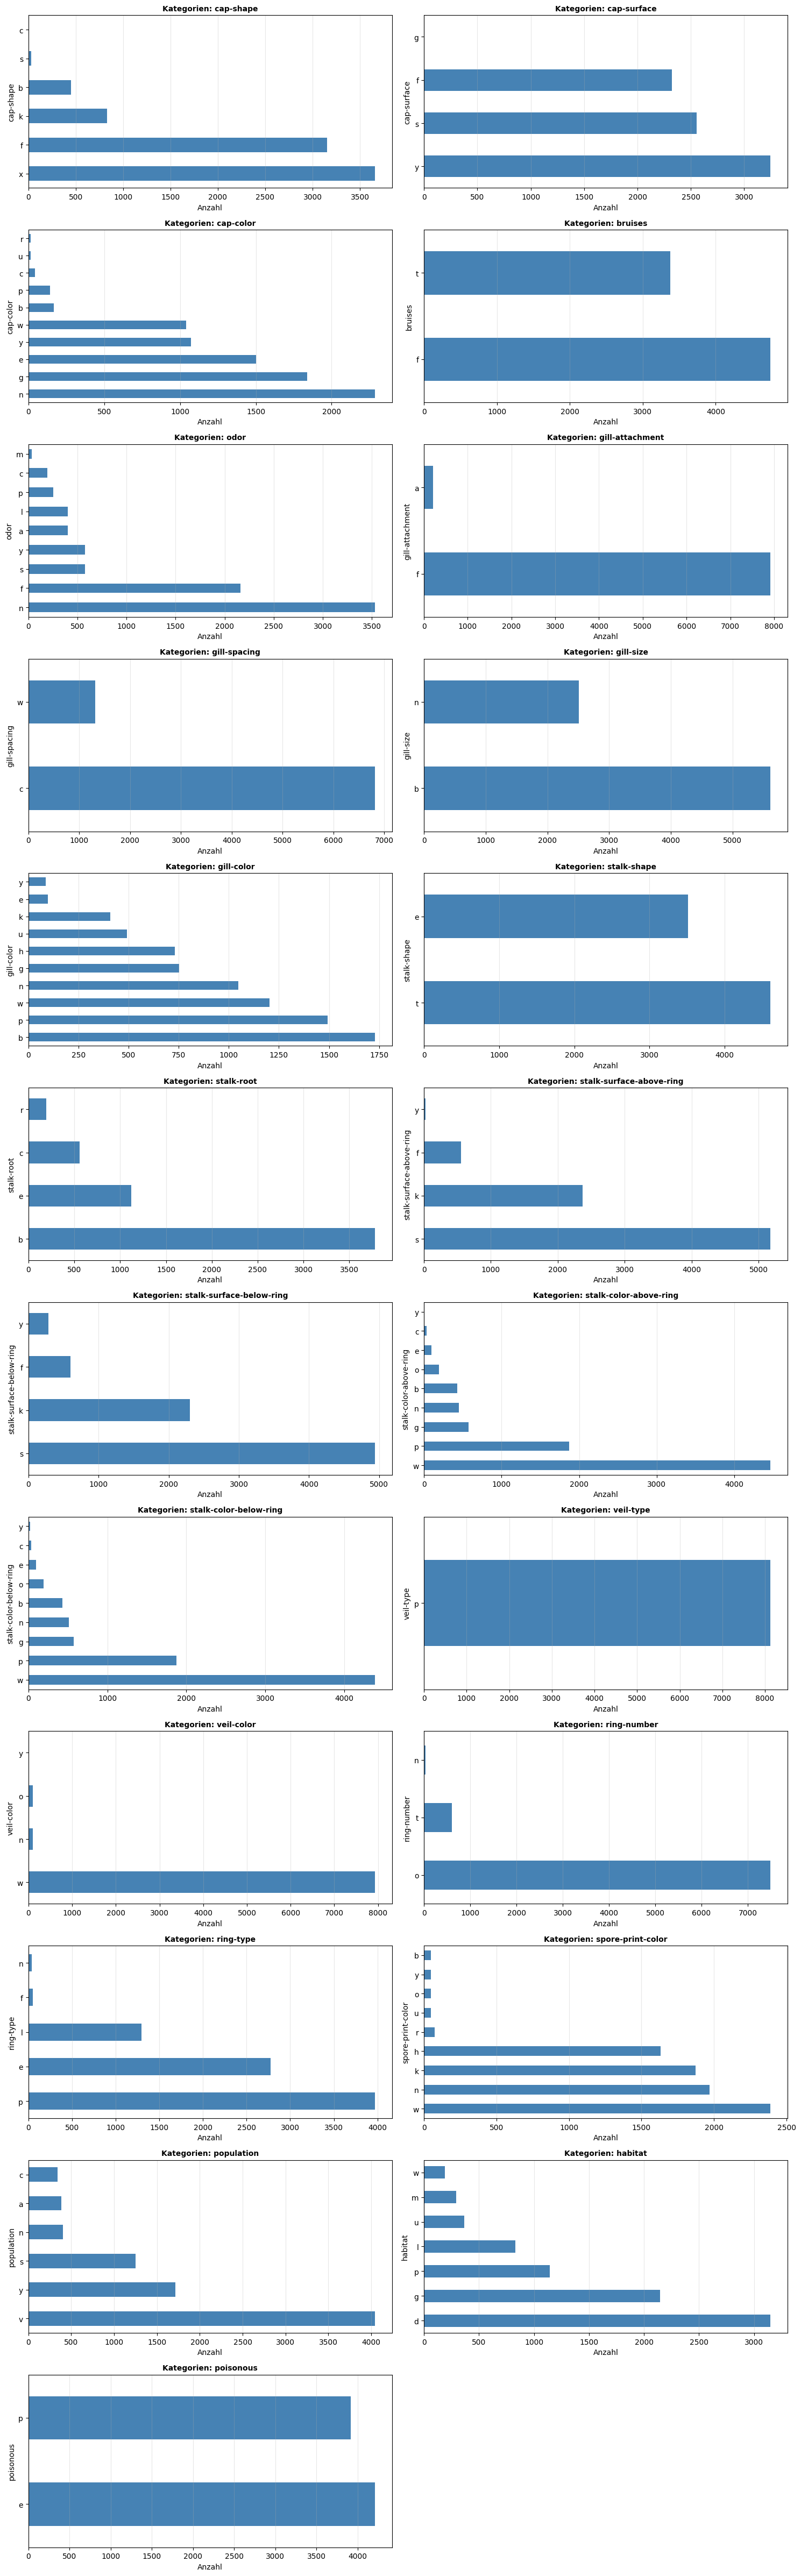

In [7]:
# Kategorien visualisieren
n_cols = min(2, len(categorical_cols))
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten() if len(categorical_cols) > 1 else [axes]

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    value_counts = df[col].value_counts().head(10)
    value_counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Kategorien: {col}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Anzahl')
    ax.grid(alpha=0.3, axis='x')

# Leere Subplots ausblenden
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()




---

## 7. Fehlende Werte visualisieren



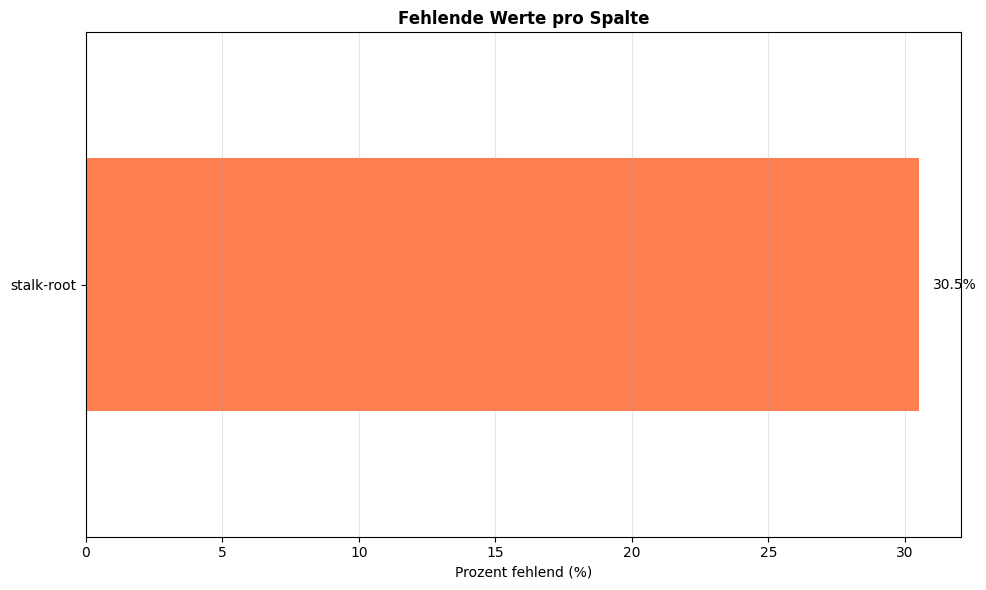

In [8]:

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(missing_data) * 0.4)))
    
    missing_percent = (missing_data / len(df) * 100)
    missing_percent.plot(kind='barh', ax=ax, color='coral')
    
    ax.set_title('Fehlende Werte pro Spalte', fontsize=12, fontweight='bold')
    ax.set_xlabel('Prozent fehlend (%)')
    ax.grid(alpha=0.3, axis='x')
    
    # Werte als Text hinzufügen
    for i, v in enumerate(missing_percent):
        ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine fehlenden Werte im Dataset!")




---

## 8. Zusammenfassung & Bewertung



In [9]:

print("=" * 80)
print("📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT")
print("=" * 80)

# Qualitätskriterien berechnen
data_quality = {
    "Datengröße": "✅ Gut" if len(df) > 5_000 else "⚠️ Klein" if len(df) > 1_000 else "❌ Zu klein",
    "Vollständigkeit": f"✅ {(1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.1f}%",
    "Duplikate": "✅ Keine" if df.duplicated().sum() == 0 else f"⚠️ {df.duplicated().sum()} gefunden",
    "Variablenvielfalt": f"{'✅' if df.shape[1] >= 10 else '⚠️'} {df.shape[1]} Spalten",
    "Numerische Features": f"{'✅' if len(numeric_cols) >= 5 else '⚠️'} {len(numeric_cols)} Spalten",
    "Kategorische Features": f"{'✅' if len(categorical_cols) >= 1 else '⚠️'} {len(categorical_cols)} Spalten"
}

for criterion, status in data_quality.items():
    print(f"{criterion:.<30} {status}")

print("\n" + "=" * 80)
print("💡 EMPFEHLUNG:")
print("=" * 80)

score = sum([
    len(df) > 5000,
    df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) < 0.1,
    df.duplicated().sum() < len(df) * 0.05,
    df.shape[1] >= 10,
    len(numeric_cols) >= 5
])

if score >= 4:
    print("✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!")
elif score >= 3:
    print("👍 OK - Dieses Dataset ist für ein Portfolio-Projekt geeignet.")
else:
    print("⚠️ BEDINGT - Überlege, ob dieses Dataset für dein Projekt ausreicht.")

print("\n📌 Nächste Schritte:")
print("   1. Definiere deine Forschungsfrage")
print("   2. Identifiziere relevante Features")
print("   3. Plane deine Analysestrategie")
print("   4. Beginne mit Feature Engineering & Modeling")


📝 DATASET-BEWERTUNG FÜR PORTFOLIO-PROJEKT
Datengröße.................... ✅ Gut
Vollständigkeit............... ✅ 98.7%
Duplikate..................... ✅ Keine
Variablenvielfalt............. ✅ 23 Spalten
Numerische Features........... ⚠️ 0 Spalten
Kategorische Features......... ✅ 23 Spalten

💡 EMPFEHLUNG:
✅ SEHR GUT - Dieses Dataset eignet sich hervorragend für ein Portfolio-Projekt!

📌 Nächste Schritte:
   1. Definiere deine Forschungsfrage
   2. Identifiziere relevante Features
   3. Plane deine Analysestrategie
   4. Beginne mit Feature Engineering & Modeling
